![Los Angeles skyline](la_skyline.jpg)

Los Angeles, California 😎. The City of Angels. Tinseltown. The Entertainment Capital of the World!

Known for its warm weather, palm trees, sprawling coastline, and Hollywood, along with producing some of the most iconic films and songs. However, as with any highly populated city, it isn't always glamorous and there can be a large volume of crime. That's where you can help!

You have been asked to support the Los Angeles Police Department (LAPD) by analyzing crime data to identify patterns in criminal behavior. They plan to use your insights to allocate resources effectively to tackle various crimes in different areas.

## The Data

They have provided you with a single dataset to use. A summary and preview are provided below.

It is a modified version of the original data, which is publicly available from Los Angeles Open Data.

# crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

In [ ]:
# Re-run this cell
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
crimes = pd.read_csv("crimes.csv", dtype={"TIME OCC": str})
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [ ]:
# Start coding here
# Use as many cells as you need

In [ ]:
crimes.duplicated().sum()

np.int64(0)

In [ ]:
crimes.isnull().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA NAME,0
Crm Cd Desc,0
Vict Age,0
Vict Sex,11
Vict Descent,10
Weapon Desc,112213


In [ ]:
crimes['Vict Sex']=crimes['Vict Sex'].replace({'X':'Not Preferred to say','H': 'Not Preferred to say' })

In [ ]:
crimes.fillna('Not Preferred to say')

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,Not Preferred to say,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,Not Preferred to say,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,Not Preferred to say,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,Not Preferred to say,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,Not Preferred to say,Invest Cont,1200 W 7TH ST
...,...,...,...,...,...,...,...,...,...,...,...,...
185710,231510379,2023-05-29,2023-05-25,1100,N Hollywood,"BUNCO, GRAND THEFT",25,M,W,Not Preferred to say,Invest Cont,5300 DENNY AV
185711,231604807,2023-01-27,2023-01-26,1800,Foothill,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",23,M,H,Not Preferred to say,Invest Cont,12500 BRANFORD ST
185712,231606525,2023-03-22,2023-03-22,1000,Foothill,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",25,F,H,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",Invest Cont,12800 FILMORE ST
185713,231210064,2023-04-12,2023-04-12,1630,77th Street,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",29,M,B,UNKNOWN WEAPON/OTHER WEAPON,Invest Cont,6100 S VERMONT AV


In [ ]:
crimes['Vict Sex'] = crimes['Vict Sex'].replace({'X': 'Not Preferred to say'}).fillna('Not Preferred to say')
crimes.isna().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA NAME,0
Crm Cd Desc,0
Vict Age,0
Vict Sex,0
Vict Descent,10
Weapon Desc,112213


In [ ]:
crimes['Vict Descent'] = crimes['Vict Descent'].fillna('Not Preferred to say')
crimes.isna().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA NAME,0
Crm Cd Desc,0
Vict Age,0
Vict Sex,0
Vict Descent,0
Weapon Desc,112213


In [ ]:
crimes['Weapon Desc'] = crimes['Weapon Desc'].fillna('No Weapon')
crimes.isna().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA NAME,0
Crm Cd Desc,0
Vict Age,0
Vict Sex,0
Vict Descent,0
Weapon Desc,0


In [ ]:
#Analysis Question 1: Crime Trends Over Time
#Let's investigate if there are any noticeable patterns in crime occurrences based on specific hours of the day, days of the week, or months.

In [ ]:
# Convert 'DATE OCC' and 'TIME OCC' to datetime objects
crimes['DATE OCC'] = pd.to_datetime(crimes['DATE OCC'])
crimes['TIME OCC'] = pd.to_datetime(crimes['TIME OCC'], format='%H%M').dt.time

# Combine date and time for full datetime object
crimes['OCCURRED DATE'] = crimes.apply(lambda row: pd.Timestamp.combine(row['DATE OCC'], row['TIME OCC']), axis=1)

# Extract time features
crimes['HOUR'] = crimes['OCCURRED DATE'].dt.hour
crimes['DAY_OF_WEEK'] = crimes['OCCURRED DATE'].dt.day_name()
crimes['MONTH'] = crimes['OCCURRED DATE'].dt.month_name()

print("Date and time columns processed and new time features extracted.")
crimes[['DATE OCC', 'TIME OCC', 'OCCURRED DATE', 'HOUR', 'DAY_OF_WEEK', 'MONTH']].head()

Date and time columns processed and new time features extracted.


,DATE OCC,TIME OCC,OCCURRED DATE,HOUR,DAY_OF_WEEK,MONTH
0,2020-05-12,11:10:00,2020-05-12 11:10:00,11,Tuesday,May
1,2020-06-04,16:20:00,2020-06-04 16:20:00,16,Thursday,June
2,2020-08-17,12:00:00,2020-08-17 12:00:00,12,Monday,August
3,2020-01-27,06:35:00,2020-01-27 06:35:00,6,Monday,January
4,2020-07-14,09:00:00,2020-07-14 09:00:00,9,Tuesday,July


In [ ]:
#Crime Count by Hour of Day

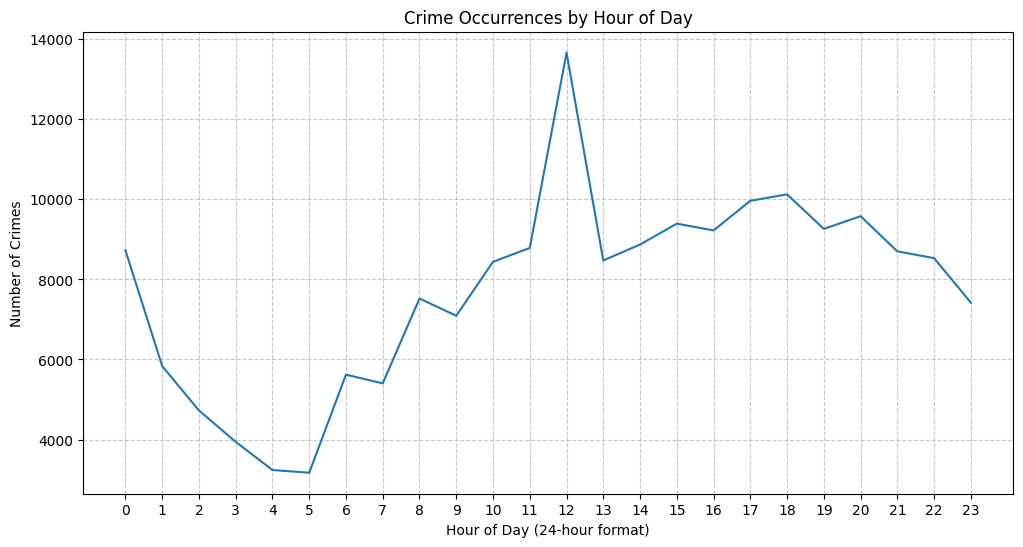

In [ ]:
#How does crime frequency vary across different hours of the day?
# Analyze crime by hour of day
crimes_by_hour = crimes['HOUR'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=crimes_by_hour.index, y=crimes_by_hour.values)
plt.title('Crime Occurrences by Hour of Day')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Crimes')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#Crime Count by Day of Week

/tmp/ipykernel_19291/2548378271.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crimes_by_day.index, y=crimes_by_day.values, palette='viridis')


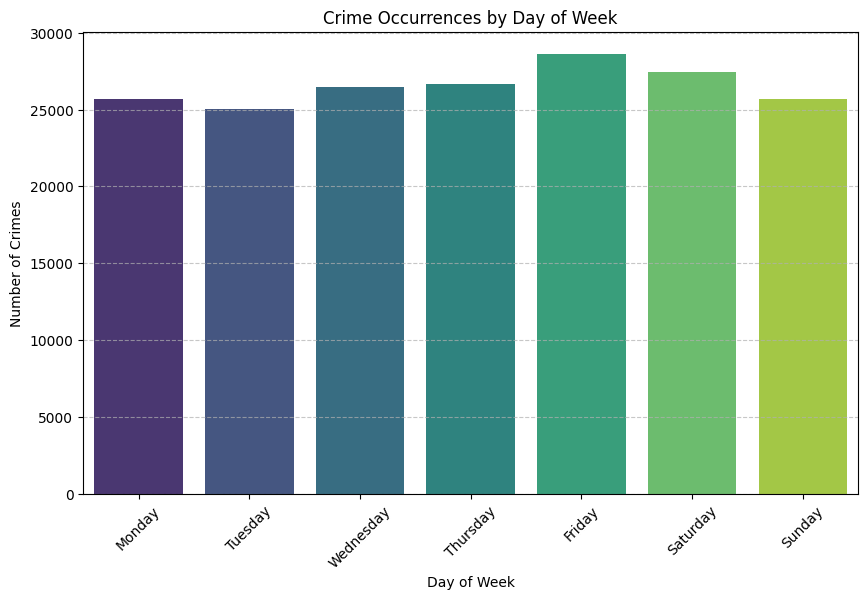

In [ ]:
#How does crime frequency vary across different day of week?
# Analyze crime by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
crimes_by_day = crimes['DAY_OF_WEEK'].value_counts().reindex(day_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=crimes_by_day.index, y=crimes_by_day.values, palette='viridis')
plt.title('Crime Occurrences by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#Crime Count by Month

/tmp/ipykernel_19291/3499230945.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crimes_by_month.index, y=crimes_by_month.values, palette='magma')


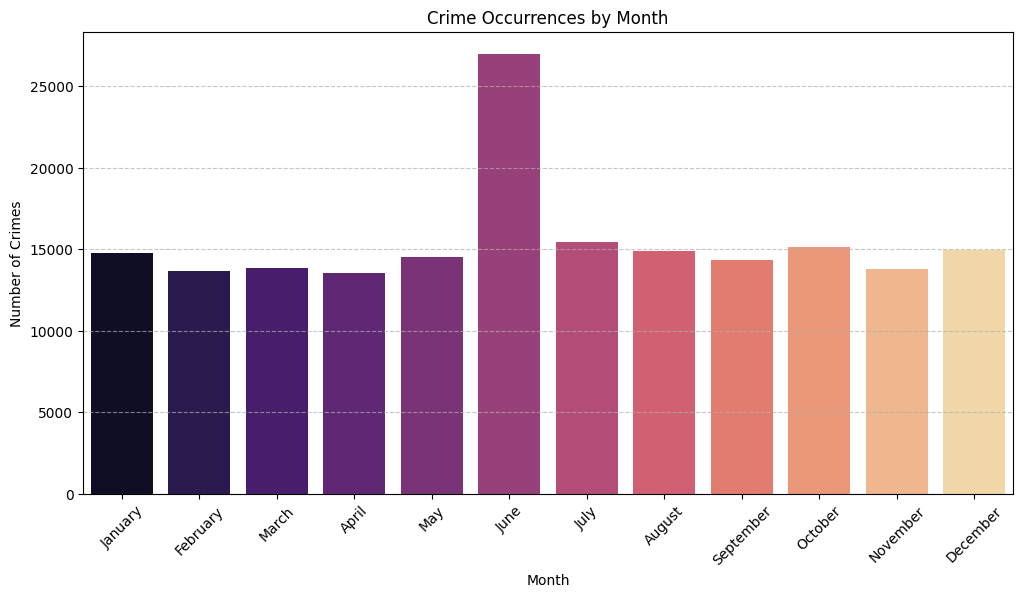

In [ ]:
#How does crime frequency vary across different month?
# Analyze crime by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
crimes_by_month = crimes['MONTH'].value_counts().reindex(month_order)

plt.figure(figsize=(12, 6))
sns.barplot(x=crimes_by_month.index, y=crimes_by_month.values, palette='magma')
plt.title('Crime Occurrences by Month')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Most Common Weapons Used:
Weapon Desc
No Weapon                                         112213
STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)     39889
UNKNOWN WEAPON/OTHER WEAPON                         7376
VERBAL THREAT                                       5894
HAND GUN                                            4395
KNIFE WITH BLADE 6INCHES OR LESS                    1608
SEMI-AUTOMATIC PISTOL                               1558
OTHER KNIFE                                         1504
UNKNOWN FIREARM                                     1222
MACE/PEPPER SPRAY                                    948
Name: count, dtype: int64


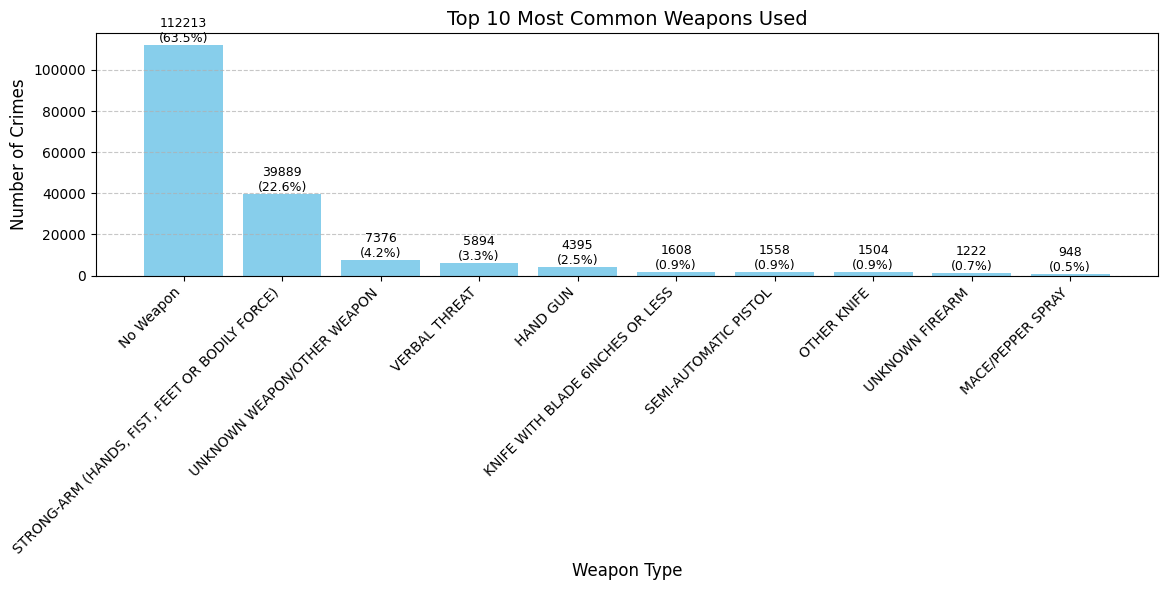

In [ ]:
#What are the most commonly used weapons in crimes?
# 4.1 Most common weapons used
print("\nMost Common Weapons Used:")
print(crimes['Weapon Desc'].value_counts().head(10))
import matplotlib.pyplot as plt

# Get top 10 weapons
top_weapons = crimes['Weapon Desc'].value_counts().head(10)

# Calculate percentages
total = top_weapons.sum()
percentages = (top_weapons / total) * 100

# Plot
plt.figure(figsize=(12,6))
bars = plt.bar(top_weapons.index, top_weapons.values, color='skyblue')

# Add titles and labels
plt.title("Top 10 Most Common Weapons Used", fontsize=14)
plt.xlabel("Weapon Type", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)

# Rotate x labels for readability
plt.xticks(rotation=45, ha='right')

# Add values + percentages on top of bars
for i, bar in enumerate(bars):
    count = top_weapons.values[i]
    percent = percentages.values[i]
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{count}\n({percent:.1f}%)',
             ha='center', va='bottom', fontsize=9)

# Add grid for clarity
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

AREA NAME
Central        14944
Southwest      11945
77th Street    11739
Pacific         9923
Hollywood       9762
Southeast       9571
Olympic         9414
Newton          9152
Van Nuys        8621
N Hollywood     8502
Name: count, dtype: int64


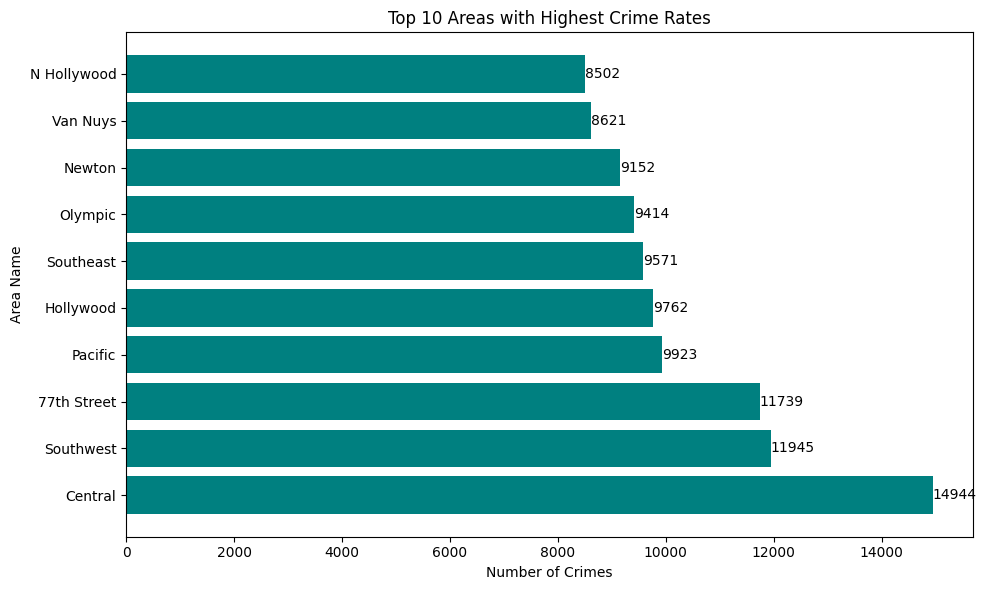

In [ ]:
#Which areas have the highest number of reported crimes?
area_counts = crimes['AREA NAME'].value_counts().head(10)
print(area_counts)
plt.figure(figsize=(10,6))
bars = plt.barh(area_counts.index, area_counts.values, color='teal')

plt.title("Top 10 Areas with Highest Crime Rates")
plt.xlabel("Number of Crimes")
plt.ylabel("Area Name")

# Add values next to bars
for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())),
             va='center')

plt.tight_layout()
plt.show()

Crm Cd Desc
THEFT OF IDENTITY                                           22670
BATTERY - SIMPLE ASSAULT                                    19694
BURGLARY FROM VEHICLE                                       13799
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              13215
INTIMATE PARTNER - SIMPLE ASSAULT                           11981
THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)         11484
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)     10719
THEFT PLAIN - PETTY ($950 & UNDER)                          10603
BURGLARY                                                    10268
THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD     7057
Name: count, dtype: int64


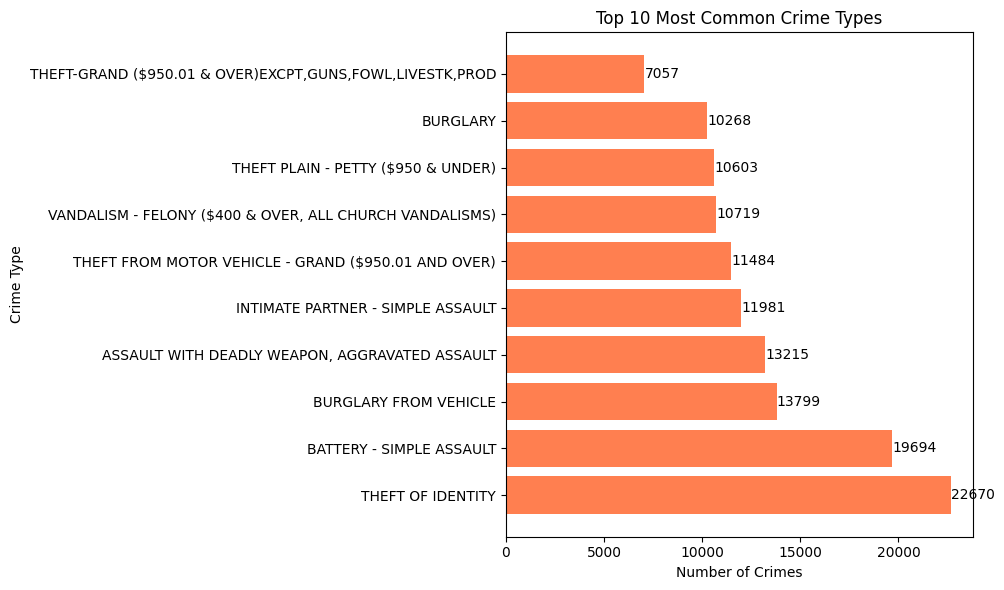

In [ ]:
#What are the most common crime types in the dataset
top_crimes = crimes['Crm Cd Desc'].value_counts().head(10)
print(top_crimes)
plt.figure(figsize=(10,6))
bars = plt.barh(top_crimes.index, top_crimes.values, color='coral')

plt.title("Top 10 Most Common Crime Types")
plt.xlabel("Number of Crimes")
plt.ylabel("Crime Type")

# Add values next to bars
for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())),
             va='center')

plt.tight_layout()
plt.show()

Vict Sex
M                       93008
F                       89854
Not Preferred to say     2853
Name: count, dtype: int64


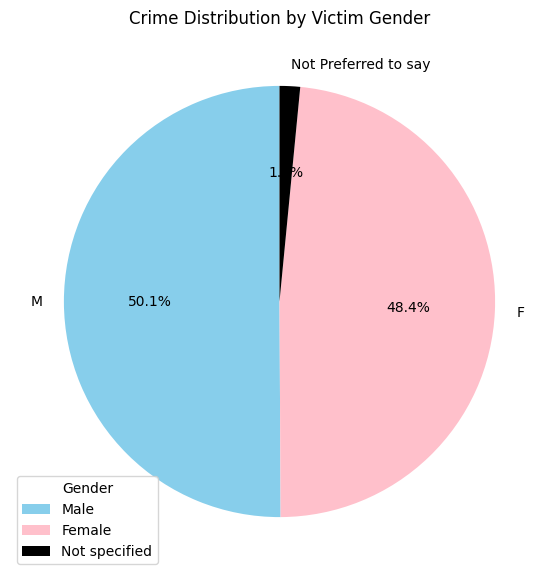

In [ ]:
#What is the distribution of crime victims by gender?
gender_counts = crimes['Vict Sex'].value_counts()
print(gender_counts)
# Count values
gender_counts = crimes['Vict Sex'].value_counts()

# Define consistent colors for each category
color_map = {
    'M': 'skyblue',
    'F': 'pink',
    'X': '#silver'
}

# Match colors to data
colors = [color_map.get(label, 'black') for label in gender_counts.index]

plt.figure(figsize=(7,7))

# Pie chart
wedges, texts, autotexts = plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title("Crime Distribution by Victim Gender")

# Create legend with matching colors
legend_labels = []
for label in gender_counts.index:
    if label == 'M':
        legend_labels.append('Male')
    elif label == 'F':
        legend_labels.append('Female')
    else:
        legend_labels.append('Not specified')

plt.legend(wedges,
           legend_labels,
           title="Gender",
           loc="lower left",
           bbox_to_anchor=(0, 0))

plt.show()